# Reconstruction Metrics Verification — New Toy Model

Verify the `lhcb_velo_toy` package ([github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model))
by sweeping the **multiple-scattering parameter** ($\sigma_{\mathrm{scatt}}$) and the
**measurement resolution** ($\sigma_{\mathrm{res}}$) for multiple track counts and two
angular-cone settings ($\phi_{\mathrm{max}} = \theta_{\mathrm{max}} \in \{0.02, 0.2\}$ rad).

**Metrics** (from `EventValidator.match_tracks`):

| Key | Definition |
|-----|-----------|
| `efficiency` | Fraction of reconstructible truth tracks matched |
| `ghost_rate` | Fraction of candidate reco tracks that are ghosts |
| `clone_fraction` | Fraction of accepted reco tracks that are clones |
| `mean_purity` | Average purity of accepted tracks |
| `hit_efficiency` | Average hit efficiency of accepted tracks |

**Fixed control parameters**: $\gamma = 1.5$, $\delta = 1.0$, scale $= 3.0$,
threshold $= 0.7$, $\theta_{\mathrm{min}} = 1.5 \times 10^{-5}$ rad.

**Computation**: Jobs were run on HTCondor (112 jobs, 20 events each).
This notebook loads the aggregated results for analysis and plotting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("results/aggregated")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

print(f"Results dir: {RESULTS_DIR.resolve()}")
print(f"Output dir:  {OUT_DIR.resolve()}")
print(f"Files found: {list(RESULTS_DIR.glob('*.csv'))}")

Results dir: /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/results/aggregated
Output dir:  /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/outputs
Files found: [PosixPath('results/aggregated/verify_scatt.csv'), PosixPath('results/aggregated/verify_scatt_per_event.csv'), PosixPath('results/aggregated/verify_res.csv'), PosixPath('results/aggregated/verify_res_per_event.csv')]


## 1. Load Condor Results & Plotting Utilities

In [2]:
# ── Load per-event results from Condor ────────────────────────────
df_scatt_raw = pd.read_csv(RESULTS_DIR / "verify_scatt_per_event.csv")
df_res_raw   = pd.read_csv(RESULTS_DIR / "verify_res_per_event.csv")

# Add derived columns
df_scatt_raw["sigma_scatt_mrad"] = df_scatt_raw["sigma_scatt"] * 1e3
df_res_raw["sigma_res_um"]       = df_res_raw["sigma_res"] * 1e3  # mm → µm

print(f"Scattering sweep: {len(df_scatt_raw)} events loaded")
print(f"Resolution sweep: {len(df_res_raw)} events loaded")

# ── Constants for plotting ────────────────────────────────────────
ANGLE_SETTINGS = sorted(df_scatt_raw["phi_max"].unique())
TRACK_COUNTS   = sorted(df_scatt_raw["n_tracks"].unique().astype(int))
N_EVENTS       = df_scatt_raw.groupby(["phi_max", "sigma_scatt", "n_tracks"]).size().iloc[0]

METRIC_LABELS = {
    "efficiency":     "Reconstruction Efficiency",
    "ghost_rate":     "Ghost Rate",
    "clone_fraction": "Clone Fraction",
    "mean_purity":    "Mean Purity",
    "hit_efficiency": "Hit Efficiency",
}
METRIC_KEYS = list(METRIC_LABELS.keys())

TRACK_COLORS = {10: "#1b7837", 20: "#2166ac", 50: "#e08214", 100: "#c51b7d"}
TRACK_FMTS   = {10: "o-",     20: "s--",     50: "D:",      100: "^-."}

def se(a):
    """Standard error of the mean (Bessel-corrected)."""
    return np.std(a, ddof=1) / np.sqrt(len(a)) if len(a) > 1 else 0.0

print(f"\nAngles: {ANGLE_SETTINGS} rad")
print(f"Track counts: {TRACK_COUNTS}")
print(f"Events per point: {N_EVENTS}")

Scattering sweep: 1120 events loaded
Resolution sweep: 1120 events loaded

Angles: [np.float64(0.02), np.float64(0.2)] rad
Track counts: [np.int64(10), np.int64(20), np.int64(50), np.int64(100)]
Events per point: 20


## 2. Scattering Parameter Sweep

Sweep $\sigma_{\mathrm{scatt}}$ with $\sigma_{\mathrm{res}} = 0$ (perfect position
resolution).  For each ($\sigma_{\mathrm{scatt}}$, $n_{\mathrm{tracks}}$, angle)
combination, 20 independent events were generated and the metrics aggregated.

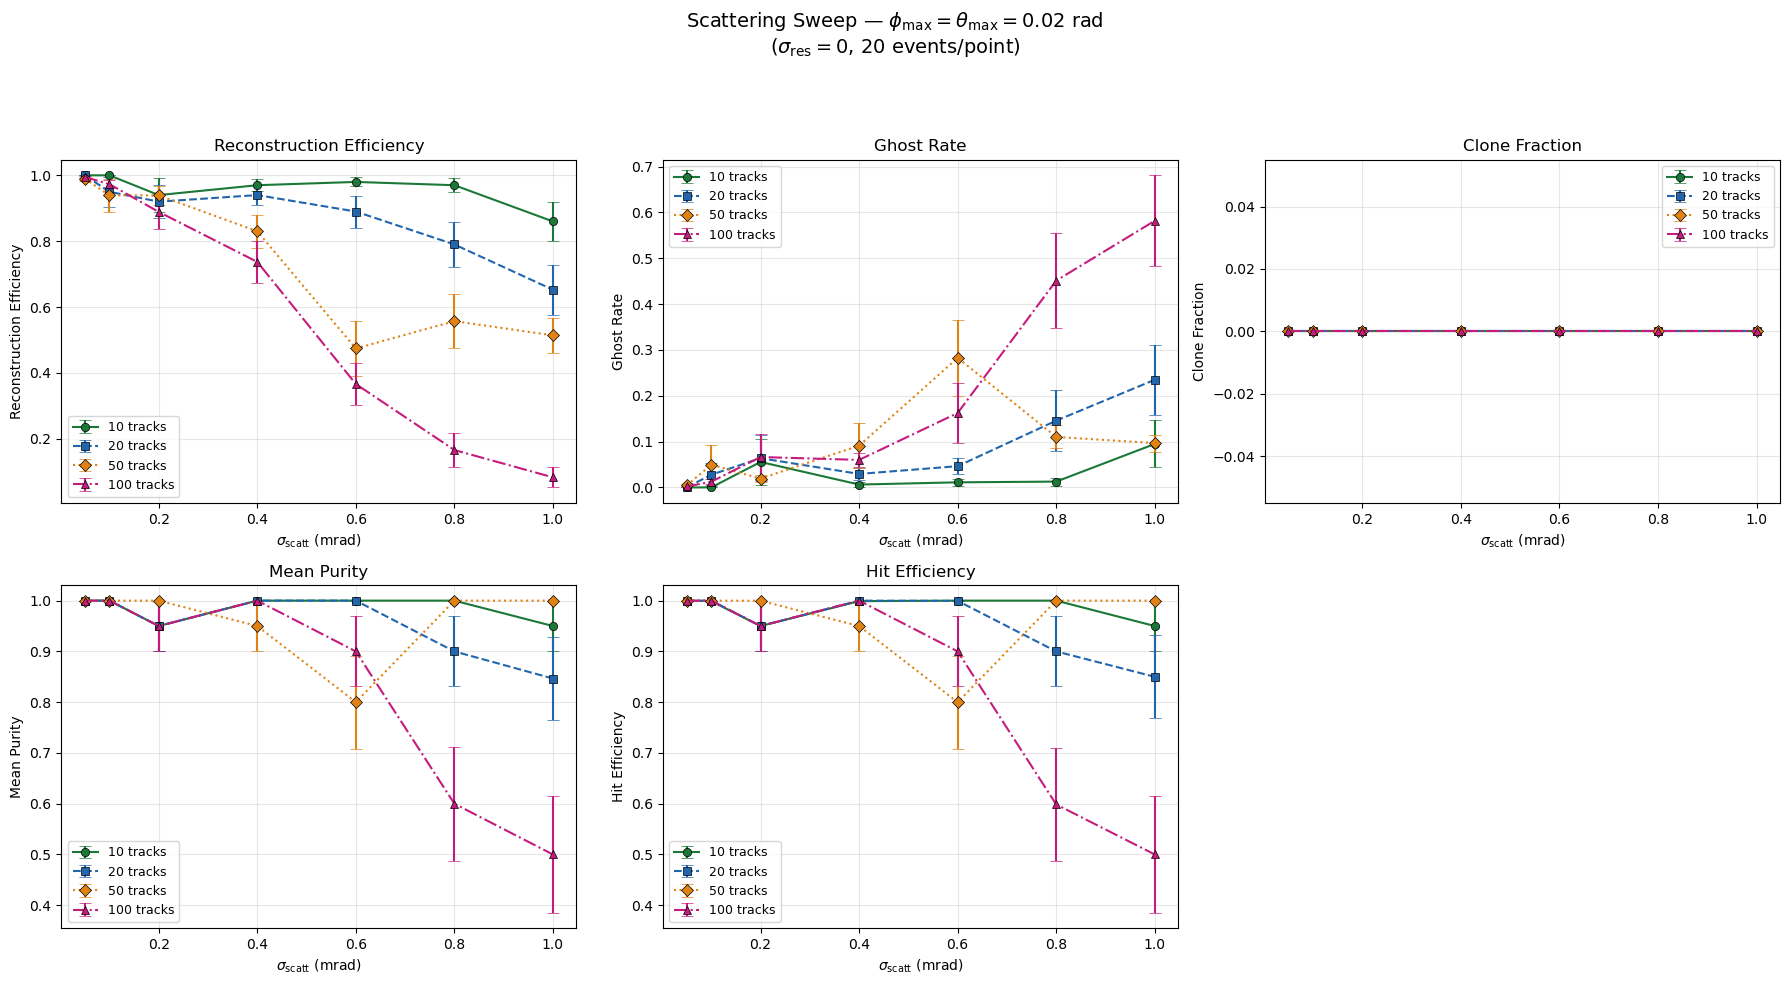

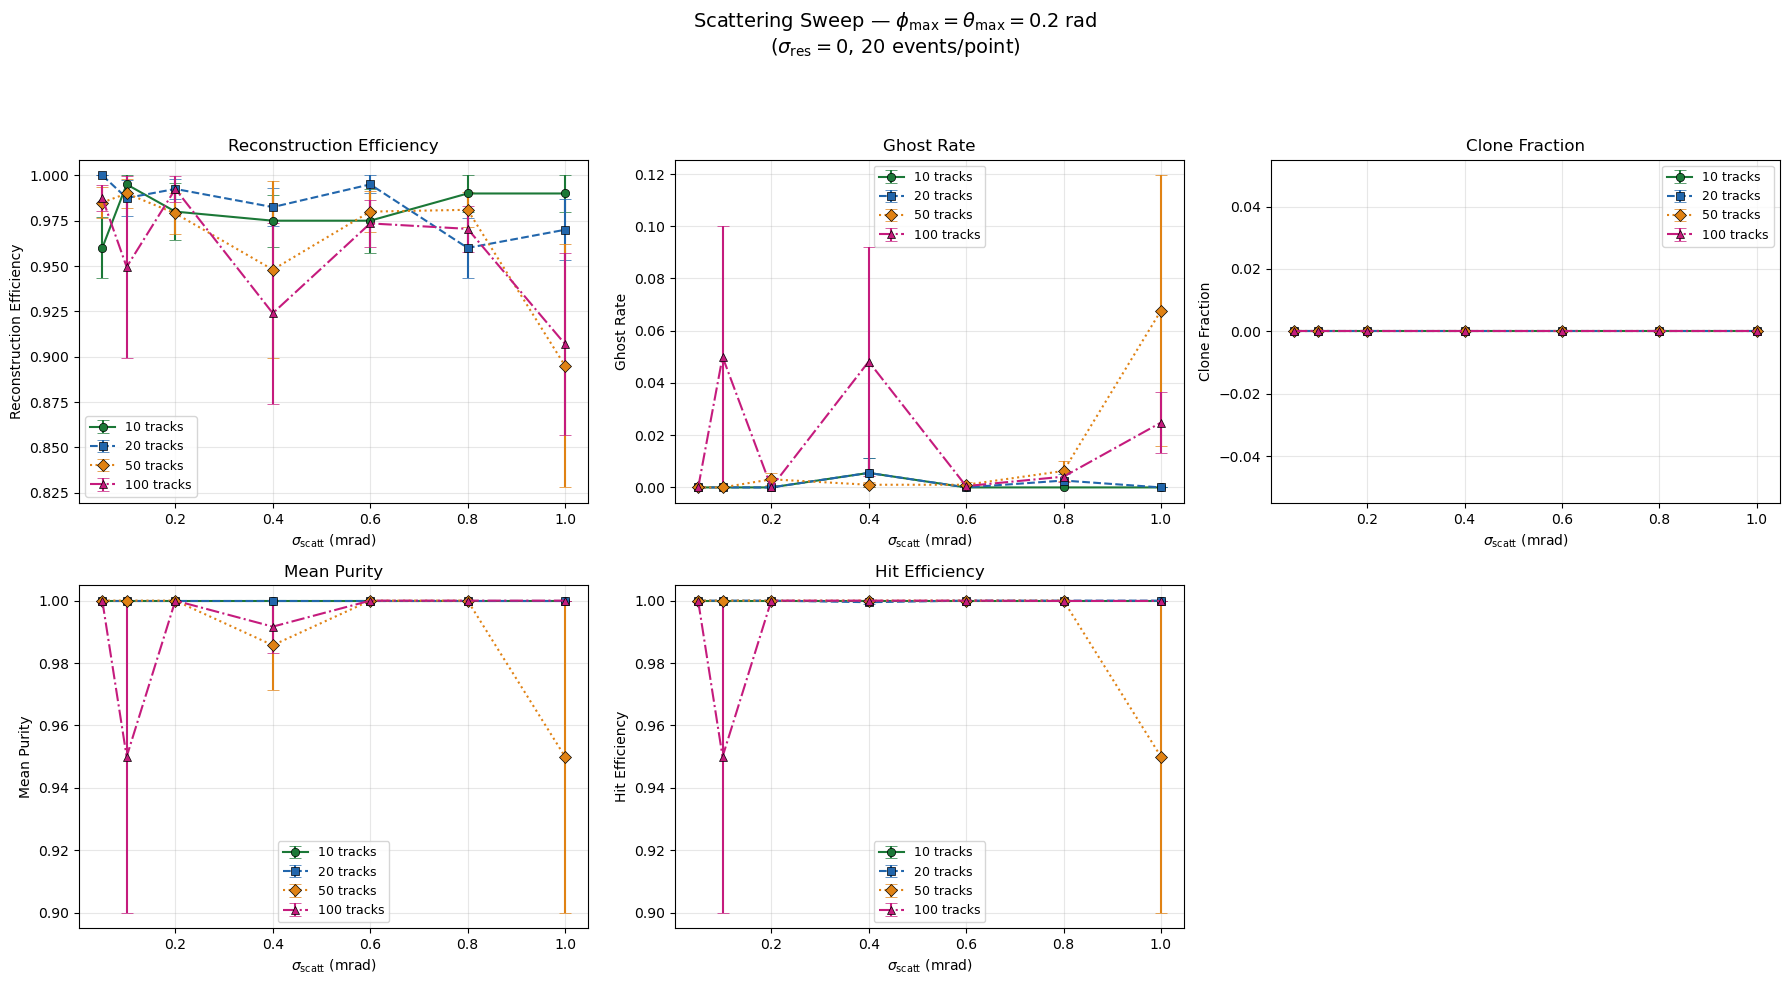

Scattering sweep plots saved.


In [3]:
for angle in ANGLE_SETTINGS:
    sub = df_scatt_raw[df_scatt_raw["phi_max"] == angle]
    agg = (sub.groupby(["sigma_scatt_mrad", "n_tracks"])
              [METRIC_KEYS].agg(["mean", se])
              .reset_index())

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(
        rf"Scattering Sweep — $\phi_{{\max}} = \theta_{{\max}} = {angle}$ rad"
        f"\n($\\sigma_{{\\mathrm{{res}}}} = 0$, {N_EVENTS} events/point)",
        fontsize=14,
    )
    axes_flat = axes.flatten()

    for ax_idx, metric in enumerate(METRIC_KEYS):
        ax = axes_flat[ax_idx]
        for n_trk in TRACK_COUNTS:
            mask = agg[("n_tracks", "")] == n_trk
            x_vals  = agg.loc[mask, ("sigma_scatt_mrad", "")].values
            y_mean  = agg.loc[mask, (metric, "mean")].values
            y_se    = agg.loc[mask, (metric, "se")].values
            ax.errorbar(
                x_vals, y_mean, yerr=y_se,
                fmt=TRACK_FMTS[n_trk], color=TRACK_COLORS[n_trk],
                capsize=4, capthick=1.2,
                markeredgecolor="black", markeredgewidth=0.5,
                label=f"{n_trk} tracks",
            )
        ax.set_xlabel(r"$\sigma_{\mathrm{scatt}}$ (mrad)")
        ax.set_ylabel(METRIC_LABELS[metric])
        ax.set_title(METRIC_LABELS[metric])
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    # hide unused subplot
    axes_flat[-1].set_visible(False)

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(OUT_DIR / f"scattering_sweep_angle_{angle}.pdf",
                bbox_inches="tight")
    fig.savefig(OUT_DIR / f"scattering_sweep_angle_{angle}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

print("Scattering sweep plots saved.")

## 3. Resolution Parameter Sweep

Sweep $\sigma_{\mathrm{res}}$ with $\sigma_{\mathrm{scatt}} = 10^{-4}$ rad (baseline
scattering).  Same track counts, events per point, and both angle settings.

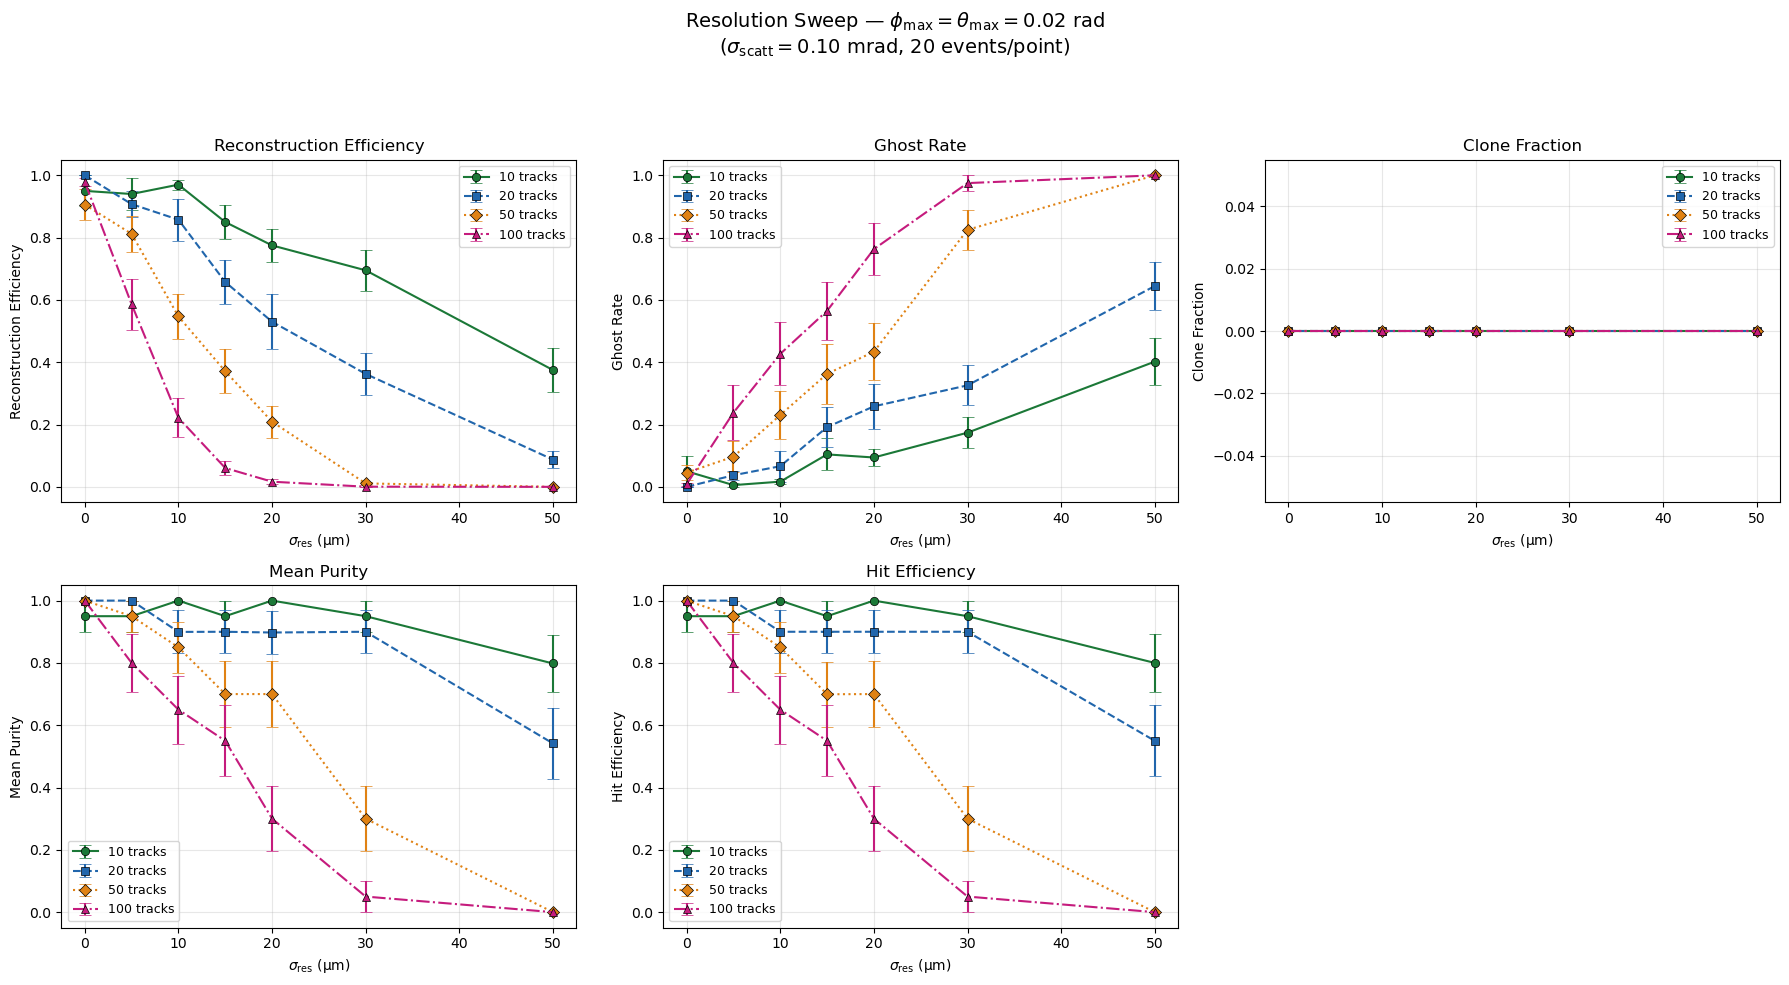

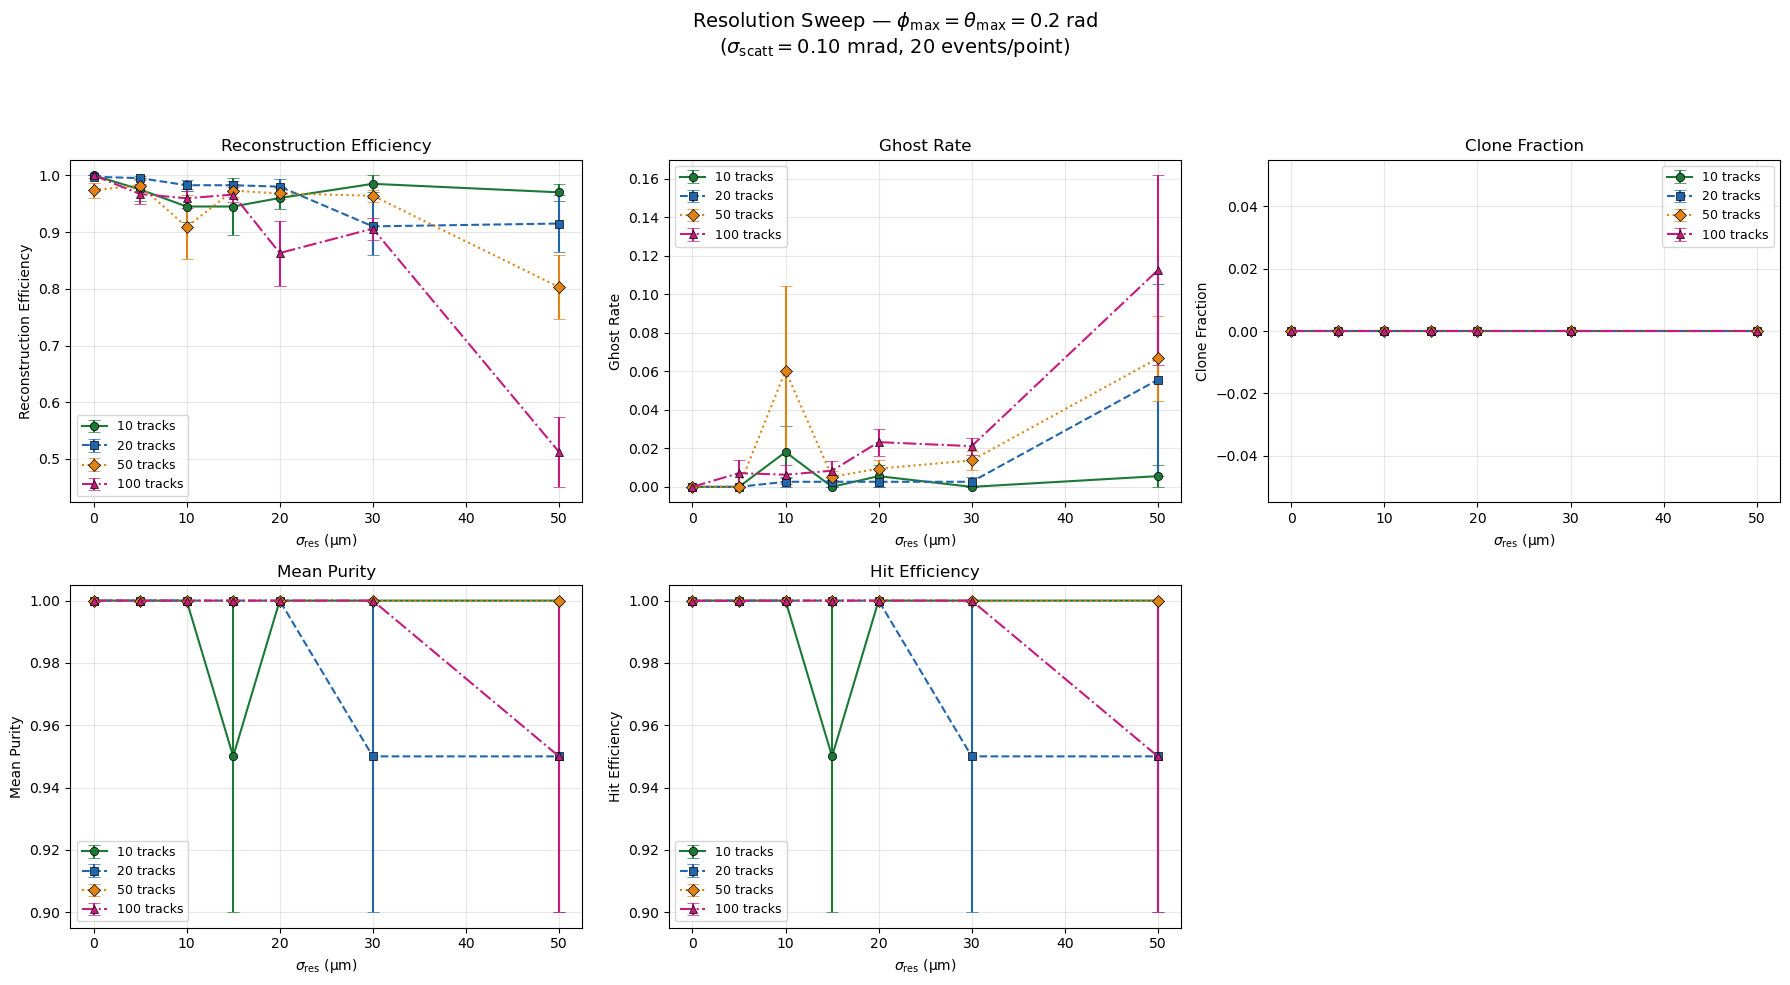

Resolution sweep plots saved.


In [4]:
SIGMA_SCATT_FIXED = df_res_raw["sigma_scatt"].iloc[0]

for angle in ANGLE_SETTINGS:
    sub = df_res_raw[df_res_raw["phi_max"] == angle]
    agg = (sub.groupby(["sigma_res_um", "n_tracks"])
              [METRIC_KEYS].agg(["mean", se])
              .reset_index())

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(
        rf"Resolution Sweep — $\phi_{{\max}} = \theta_{{\max}} = {angle}$ rad"
        f"\n($\\sigma_{{\\mathrm{{scatt}}}} = {SIGMA_SCATT_FIXED*1e3:.2f}$ mrad, "
        f"{N_EVENTS} events/point)",
        fontsize=14,
    )
    axes_flat = axes.flatten()

    for ax_idx, metric in enumerate(METRIC_KEYS):
        ax = axes_flat[ax_idx]
        for n_trk in TRACK_COUNTS:
            mask = agg[("n_tracks", "")] == n_trk
            x_vals  = agg.loc[mask, ("sigma_res_um", "")].values
            y_mean  = agg.loc[mask, (metric, "mean")].values
            y_se    = agg.loc[mask, (metric, "se")].values
            ax.errorbar(
                x_vals, y_mean, yerr=y_se,
                fmt=TRACK_FMTS[n_trk], color=TRACK_COLORS[n_trk],
                capsize=4, capthick=1.2,
                markeredgecolor="black", markeredgewidth=0.5,
                label=f"{n_trk} tracks",
            )
        ax.set_xlabel(r"$\sigma_{\mathrm{res}}$ (µm)")
        ax.set_ylabel(METRIC_LABELS[metric])
        ax.set_title(METRIC_LABELS[metric])
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    axes_flat[-1].set_visible(False)

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(OUT_DIR / f"resolution_sweep_angle_{angle}.pdf",
                bbox_inches="tight")
    fig.savefig(OUT_DIR / f"resolution_sweep_angle_{angle}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

print("Resolution sweep plots saved.")

## 4. Baseline Sanity Check

Check the lowest-noise point in the scattering sweep ($\sigma_{\mathrm{scatt}} = 0.05$ mrad,
$\sigma_{\mathrm{res}} = 0$, 10 tracks).  We expect near-perfect reconstruction:
efficiency $\approx 1$, ghost rate $\approx 0$.

In [5]:
# Use the lowest sigma_scatt, smallest n_tracks from the sweep data
sigma_min = df_scatt_raw["sigma_scatt"].min()
n_trk_check = 10

for angle in ANGLE_SETTINGS:
    sub = df_scatt_raw[
        (df_scatt_raw["phi_max"] == angle) &
        (df_scatt_raw["sigma_scatt"] == sigma_min) &
        (df_scatt_raw["n_tracks"] == n_trk_check)
    ]
    mean_eff   = sub["efficiency"].mean()
    mean_ghost = sub["ghost_rate"].mean()
    pass_eff   = mean_eff >= 0.95
    pass_ghost = mean_ghost <= 0.05

    status = "PASS" if (pass_eff and pass_ghost) else "FAIL"
    print(f"angle={angle:5.3f} rad  σ_scatt={sigma_min:.1e}  n={n_trk_check} │ "
          f"efficiency = {mean_eff:.3f} ({'✓' if pass_eff else '✗'})  "
          f"ghost_rate = {mean_ghost:.3f} ({'✓' if pass_ghost else '✗'})  "
          f"│ {status}")

angle=0.020 rad  σ_scatt=5.0e-05  n=10 │ efficiency = 1.000 (✓)  ghost_rate = 0.000 (✓)  │ PASS
angle=0.200 rad  σ_scatt=5.0e-05  n=10 │ efficiency = 0.960 (✓)  ghost_rate = 0.000 (✓)  │ PASS


## 5. Summary Tables

Mean $\pm$ std for each ($n_{\mathrm{tracks}}$, angle) combination at each sweep point.

In [6]:
def summary_table(df, sweep_col, sweep_label):
    """Pretty-print a grouped summary for one sweep DataFrame."""
    agg = (df.groupby(["phi_max", "n_tracks", sweep_col])
              [METRIC_KEYS].agg(["mean", "std", "count"])
              .reset_index())

    # Flatten MultiIndex columns
    agg.columns = [
        f"{c[0]}_{c[1]}" if c[1] else c[0]
        for c in agg.columns
    ]

    # Format for display
    display_cols = ["phi_max", "n_tracks", sweep_col]
    for m in METRIC_KEYS:
        agg[m] = agg.apply(
            lambda r, m=m: f"{r[f'{m}_mean']:.3f} ± {r[f'{m}_std']:.3f}", axis=1
        )
        display_cols.append(m)

    print(f"\n{'='*100}")
    print(f"  {sweep_label} Summary (mean ± std)")
    print(f"{'='*100}")
    with pd.option_context("display.max_rows", None, "display.max_columns", None,
                           "display.width", 200):
        display(agg[display_cols])
    return agg

agg_scatt = summary_table(df_scatt_raw, "sigma_scatt_mrad",
                           "Scattering Sweep (σ_scatt in mrad)")
agg_res   = summary_table(df_res_raw, "sigma_res_um",
                           "Resolution Sweep (σ_res in µm)")


  Scattering Sweep (σ_scatt in mrad) Summary (mean ± std)


,phi_max,n_tracks,sigma_scatt_mrad,efficiency,ghost_rate,clone_fraction,mean_purity,hit_efficiency
0,0.02,10,0.05,1.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
1,0.02,10,0.10,1.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000,0.999 ± 0.004
2,0.02,10,0.20,0.940 ± 0.226,0.056 ± 0.224,0.000 ± 0.000,0.950 ± 0.224,0.950 ± 0.224
3,0.02,10,0.40,0.970 ± 0.080,0.006 ± 0.028,0.000 ± 0.000,1.000 ± 0.000,0.999 ± 0.004
4,0.02,10,0.60,0.980 ± 0.062,0.011 ± 0.034,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
5,0.02,10,0.80,0.970 ± 0.098,0.013 ± 0.039,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
6,0.02,10,1.00,0.860 ± 0.260,0.095 ± 0.229,0.000 ± 0.000,0.950 ± 0.224,0.950 ± 0.224
7,0.02,20,0.05,1.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
8,0.02,20,0.10,0.950 ± 0.201,0.028 ± 0.112,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
9,0.02,20,0.20,0.920 ± 0.226,0.064 ± 0.222,0.000 ± 0.000,0.950 ± 0.224,0.950 ± 0.224



  Resolution Sweep (σ_res in µm) Summary (mean ± std)


,phi_max,n_tracks,sigma_res_um,efficiency,ghost_rate,clone_fraction,mean_purity,hit_efficiency
0,0.02,10,0.0,0.950 ± 0.224,0.050 ± 0.224,0.000 ± 0.000,0.950 ± 0.224,0.950 ± 0.224
1,0.02,10,5.0,0.940 ± 0.226,0.006 ± 0.025,0.000 ± 0.000,0.950 ± 0.224,0.950 ± 0.224
2,0.02,10,10.0,0.970 ± 0.073,0.017 ± 0.041,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
3,0.02,10,15.0,0.850 ± 0.250,0.104 ± 0.230,0.000 ± 0.000,0.950 ± 0.224,0.950 ± 0.224
4,0.02,10,20.0,0.775 ± 0.240,0.094 ± 0.123,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
5,0.02,10,30.0,0.695 ± 0.291,0.174 ± 0.222,0.000 ± 0.000,0.950 ± 0.224,0.950 ± 0.224
6,0.02,10,50.0,0.375 ± 0.309,0.402 ± 0.335,0.000 ± 0.000,0.798 ± 0.410,0.800 ± 0.410
7,0.02,20,0.0,1.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
8,0.02,20,5.0,0.907 ± 0.188,0.037 ± 0.068,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
9,0.02,20,10.0,0.857 ± 0.300,0.066 ± 0.222,0.000 ± 0.000,0.900 ± 0.308,0.900 ± 0.308


In [7]:
# Save per-event CSVs to outputs/ for convenience
df_scatt_raw.to_csv(OUT_DIR / "scattering_sweep_results.csv", index=False)
df_res_raw.to_csv(OUT_DIR / "resolution_sweep_results.csv", index=False)

print("All outputs saved to:")
for f in sorted(OUT_DIR.glob("*")):
    print(f"  {f}")

All outputs saved to:
  outputs/event_size_clone_fraction.pdf
  outputs/event_size_clone_fraction.png
  outputs/event_size_efficiency.pdf
  outputs/event_size_efficiency.png
  outputs/event_size_ghost_rate.pdf
  outputs/event_size_ghost_rate.png
  outputs/event_size_hit_efficiency.pdf
  outputs/event_size_hit_efficiency.png
  outputs/event_size_mean_purity.pdf
  outputs/event_size_mean_purity.png
  outputs/event_size_sweep.pdf
  outputs/event_size_sweep.png
  outputs/event_size_sweep_results.csv
  outputs/resolution_sweep_angle_0.02.pdf
  outputs/resolution_sweep_angle_0.02.png
  outputs/resolution_sweep_angle_0.2.pdf
  outputs/resolution_sweep_angle_0.2.png
  outputs/resolution_sweep_results.csv
  outputs/scattering_sweep_angle_0.02.pdf
  outputs/scattering_sweep_angle_0.02.png
  outputs/scattering_sweep_angle_0.2.pdf
  outputs/scattering_sweep_angle_0.2.png
  outputs/scattering_sweep_results.csv
  outputs/segment_analysis


---

## 6. Reconstruction Metrics vs Event Size

Sweep the number of tracks from 10 to 190 (step 20) with fixed physics parameters:

| Parameter | Value |
|-----------|-------|
| $\sigma_{\mathrm{scatt}}$ | $0.1\;\mathrm{mrad} = 10^{-4}\;\mathrm{rad}$ |
| $\sigma_{\mathrm{res}}$ | $5\;\mu\mathrm{m} = 0.005\;\mathrm{mm}$ |
| $\gamma$ | 3.0 |
| $\delta$ | 1.0 |
| scale | 3.0 |
| $\phi_{\max} = \theta_{\max}$ | 0.2 rad |
| Events per point | 10 |

Derived: baseline $= \delta/(\delta+\gamma) = 0.25$, max chain activation $= \delta/(\delta+\gamma-2) = 0.5$, corrected threshold $= (0.25 + 0.50)/2 = 0.375$.

**Note:** Uses `AcceleratedHamiltonian` (Numba-parallel) for speed at larger event sizes.

In [ ]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

from lhcb_velo_toy.generation import PlaneGeometry, StateEventGenerator
from lhcb_velo_toy.analysis import EventValidator

# AcceleratedHamiltonian (Numba-parallel, drop-in for SimpleHamiltonianFast)
sys.path.insert(0, str(Path.cwd()))
from accelerated_hamiltonian import AcceleratedHamiltonian, get_tracks_accel

# ── Fixed physics parameters ──────────────────────────────────────
SIGMA_SCATT  = 1e-4      # 0.1 mrad (rad)
SIGMA_RES    = 0.005      # 5 µm (mm)
GAMMA_ES     = 3.0        # self-interaction penalty
DELTA_ES     = 1.0        # bias weight
SCALE_ES     = 3.0        # sigma scale factor
THETA_MIN_ES = 1.5e-5     # numerical floor (rad)

# ── Detector geometry ─────────────────────────────────────────────
DZ_MM     = 33.0
N_MODULES = 5
Z_FIRST   = 100.0
HALF_X    = 50.0
HALF_Y    = 50.0

z_positions = [Z_FIRST + i * DZ_MM for i in range(N_MODULES)]
geo_es = PlaneGeometry(
    module_id=list(range(N_MODULES)),
    lx=[HALF_X] * N_MODULES,
    ly=[HALF_Y] * N_MODULES,
    z=z_positions,
)

# ── Derived quantities ────────────────────────────────────────────
BASELINE_ES  = DELTA_ES / (DELTA_ES + GAMMA_ES)          # 0.25
MAX_CHAIN_ES = DELTA_ES / (DELTA_ES + GAMMA_ES - 2)      # 0.50
THRESHOLD_ES = (BASELINE_ES + MAX_CHAIN_ES) / 2           # 0.375

theta_s = SCALE_ES * SIGMA_SCATT
theta_r = np.arctan((SCALE_ES * SIGMA_RES) / DZ_MM)
EPSILON_ES = float(np.sqrt(2 * theta_s**2 + 12 * theta_r**2 + 2 * THETA_MIN_ES**2))

# ── Sweep configuration ──────────────────────────────────────────
TRACK_COUNTS_ES = list(range(10, 201, 20))  # [10, 30, 50, ..., 190]
N_EVENTS_ES     = 10                        # events per track-count point
PHI_MAX_ES      = 0.2                       # angular cone (rad)

print(f"σ_scatt  = {SIGMA_SCATT*1e3:.1f} mrad")
print(f"σ_res    = {SIGMA_RES*1e3:.1f} µm")
print(f"γ        = {GAMMA_ES}")
print(f"δ        = {DELTA_ES}")
print(f"baseline = {BASELINE_ES:.4f}")
print(f"max chain= {MAX_CHAIN_ES:.4f}")
print(f"threshold= {THRESHOLD_ES:.4f}")
print(f"ε        = {EPSILON_ES*1e3:.4f} mrad")
print(f"Track counts: {TRACK_COUNTS_ES}")
print(f"Events/point: {N_EVENTS_ES}")

σ_scatt  = 0.1 mrad
σ_res    = 5.0 µm
γ        = 3.0
δ        = 1.0
baseline = 0.2500
threshold= 0.6250
ε        = 1.6309 mrad
Track counts: [10, 30, 50, 70, 90, 110, 130, 150, 170, 190]
Events/point: 10


In [ ]:
import time

def generate_event_es(n_tracks):
    """Generate one event with the study parameters, retrying until all tracks have ≥3 hits."""
    for _ in range(20):
        gen = StateEventGenerator(
            detector_geometry=geo_es,
            events=1,
            n_particles=[n_tracks],
            phi_min=-PHI_MAX_ES,
            phi_max=PHI_MAX_ES,
            theta_min=-PHI_MAX_ES,
            theta_max=PHI_MAX_ES,
            measurement_error=SIGMA_RES,
            collision_noise=SIGMA_SCATT,
        )
        gen.generate_random_primary_vertices({"x": 0.1, "y": 0.1, "z": 50.0})
        gen.generate_particles([[{"type": "pion", "mass": 139.6, "q": 1}] * n_tracks])
        event = gen.generate_complete_events()
        if event.tracks and min(len(t.hit_ids) for t in event.tracks) >= 3:
            return event
    return event  # best effort


def solve_and_validate(event):
    """Build AcceleratedHamiltonian, solve classically, reconstruct, and return metrics."""
    ham = AcceleratedHamiltonian(epsilon=EPSILON_ES, gamma=GAMMA_ES, delta=DELTA_ES)
    ham.construct_hamiltonian(event)
    x = ham.solve_classicaly()

    reco_tracks = get_tracks_accel(ham, x, event, threshold=THRESHOLD_ES)
    if len(reco_tracks) == 0:
        return {
            "efficiency": 0.0, "ghost_rate": 0.0,
            "clone_fraction": 0.0, "mean_purity": 0.0,
            "hit_efficiency": 0.0,
        }

    val = EventValidator(event, reco_tracks)
    _, metrics = val.match_tracks(purity_min=0.7)
    metrics.setdefault("clone_fraction", 0.0)
    return metrics


# ── Main sweep ────────────────────────────────────────────────────
rows = []
t0 = time.time()

for n_trk in TRACK_COUNTS_ES:
    for ev_idx in range(N_EVENTS_ES):
        event = generate_event_es(n_trk)
        metrics = solve_and_validate(event)
        rows.append({"n_tracks": n_trk, "event": ev_idx, **metrics})

    elapsed = time.time() - t0
    print(f"  n_tracks={n_trk:4d}  done ({elapsed:.1f}s elapsed)")

df_es = pd.DataFrame(rows)
print(f"\nSweep complete: {len(df_es)} events collected in {time.time()-t0:.1f}s")
df_es.head()

  n_tracks=  10  done (0.4s elapsed)
  n_tracks=  30  done (11.4s elapsed)
  n_tracks=  50  done (69.1s elapsed)
  n_tracks=  70  done (252.9s elapsed)
  n_tracks=  90  done (697.4s elapsed)
  n_tracks= 110  done (1622.1s elapsed)
  n_tracks= 130  done (3293.8s elapsed)
  n_tracks= 150  done (6060.0s elapsed)
  n_tracks= 170  done (10103.4s elapsed)
  n_tracks= 190  done (16728.3s elapsed)

Sweep complete: 100 events collected in 16728.3s


,n_tracks,event,efficiency,ghost_rate,clone_fraction,mean_purity,hit_efficiency,n_candidates,n_accepted,n_ghosts,n_clones,n_primary,n_reconstructible,n_matched
0,10,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,2,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10,3,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10,4,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# ── Aggregate: mean ± SE per track count ──────────────────────────
ES_METRIC_KEYS = ["efficiency", "ghost_rate", "clone_fraction", "mean_purity", "hit_efficiency"]
ES_METRIC_LABELS = {
    "efficiency":     "Reconstruction Efficiency",
    "ghost_rate":     "Ghost Rate",
    "clone_fraction": "Clone Fraction",
    "mean_purity":    "Mean Purity",
    "hit_efficiency": "Hit Efficiency",
}

def _se(a):
    return np.std(a, ddof=1) / np.sqrt(len(a)) if len(a) > 1 else 0.0

agg_es = (df_es.groupby("n_tracks")[ES_METRIC_KEYS]
          .agg(["mean", _se, "std"])
          .reset_index())

# Build a readable summary table
summary_rows = []
for _, row in agg_es.iterrows():
    r = {"n_tracks": int(row[("n_tracks", "")])}
    for m in ES_METRIC_KEYS:
        r[m] = f"{row[(m, 'mean')]:.4f} ± {row[(m, 'std')]:.4f}"
    summary_rows.append(r)

df_summary_es = pd.DataFrame(summary_rows)
print("Reconstruction Metrics vs Event Size  (mean ± std)")
print(f"σ_scatt = {SIGMA_SCATT*1e3:.1f} mrad,  σ_res = {SIGMA_RES*1e3:.1f} µm,  γ = {GAMMA_ES}")
display(df_summary_es)

Reconstruction Metrics vs Event Size  (mean ± std)
σ_scatt = 0.1 mrad,  σ_res = 5.0 µm,  γ = 3.0


,n_tracks,efficiency,ghost_rate,clone_fraction,mean_purity,hit_efficiency
0,10,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000
1,30,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000
2,50,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000
3,70,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000
4,90,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000
5,110,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000
6,130,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000
7,150,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000
8,170,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000
9,190,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000


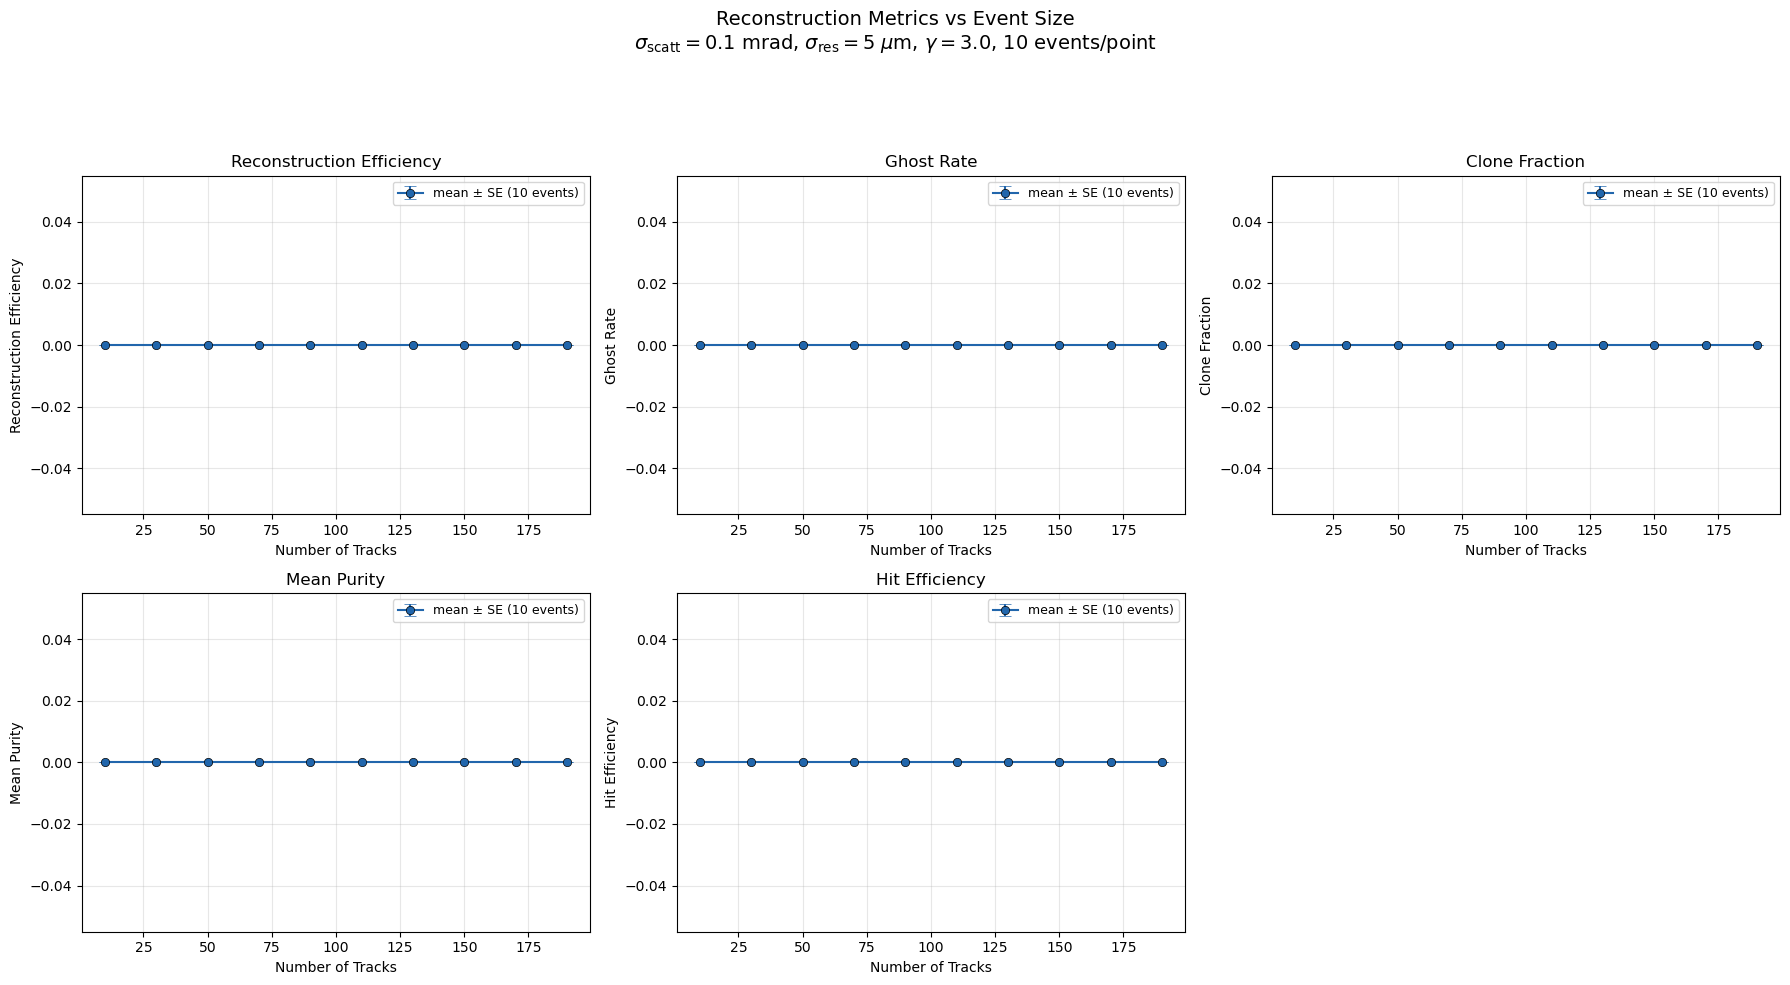

Event-size sweep plots saved.


In [11]:
# ── Plot all five metrics vs event size ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Reconstruction Metrics vs Event Size\n"
    rf"$\sigma_{{\mathrm{{scatt}}}} = {SIGMA_SCATT*1e3:.1f}$ mrad, "
    rf"$\sigma_{{\mathrm{{res}}}} = {SIGMA_RES*1e3:.0f}\;\mu$m, "
    rf"$\gamma = {GAMMA_ES}$, "
    f"{N_EVENTS_ES} events/point",
    fontsize=14,
)
axes_flat = axes.flatten()

x_vals = agg_es[("n_tracks", "")].values

for ax_idx, metric in enumerate(ES_METRIC_KEYS):
    ax = axes_flat[ax_idx]
    y_mean = agg_es[(metric, "mean")].values
    y_se   = agg_es[(metric, "_se")].values

    ax.errorbar(
        x_vals, y_mean, yerr=y_se,
        fmt="o-", color="#2166ac",
        capsize=4, capthick=1.2,
        markeredgecolor="black", markeredgewidth=0.5,
        label=f"mean ± SE ({N_EVENTS_ES} events)",
    )
    ax.set_xlabel("Number of Tracks")
    ax.set_ylabel(ES_METRIC_LABELS[metric])
    ax.set_title(ES_METRIC_LABELS[metric])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# hide unused subplot
axes_flat[-1].set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.91])
fig.savefig(OUT_DIR / "event_size_sweep.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "event_size_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Event-size sweep plots saved.")

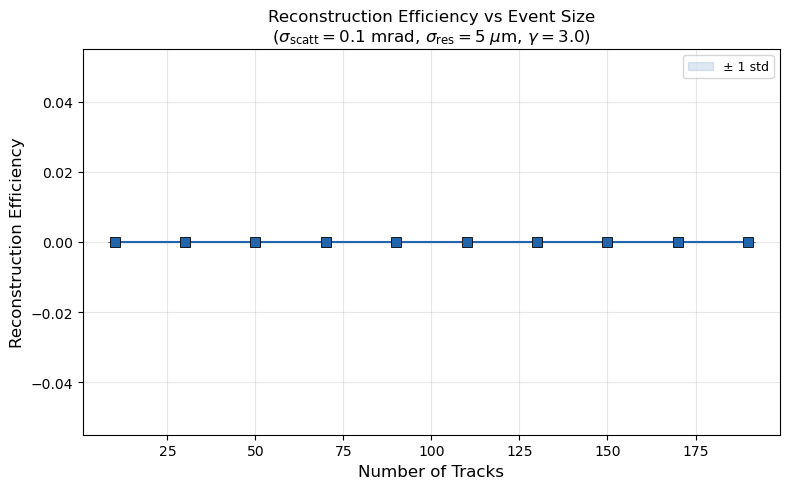

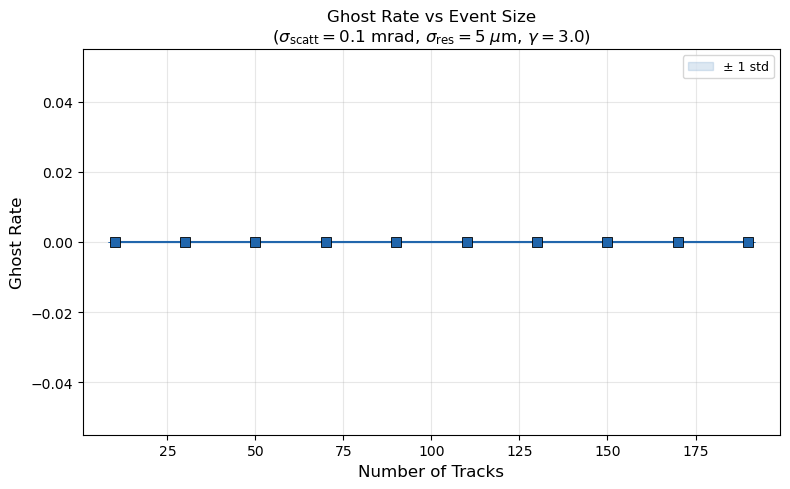

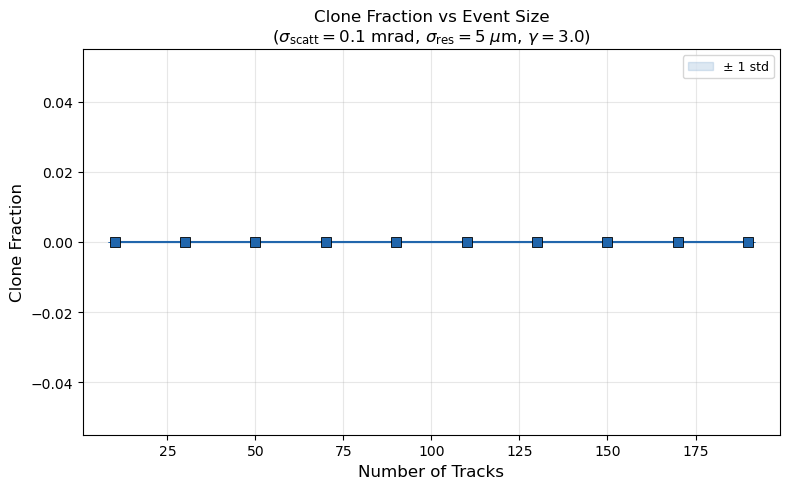

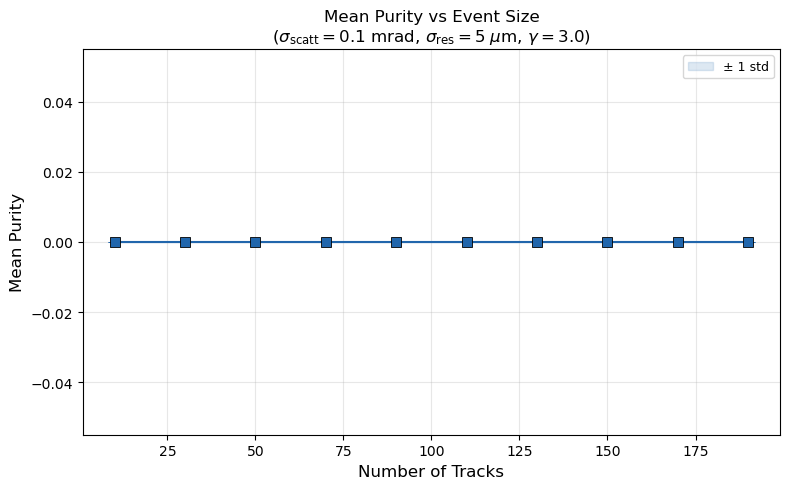

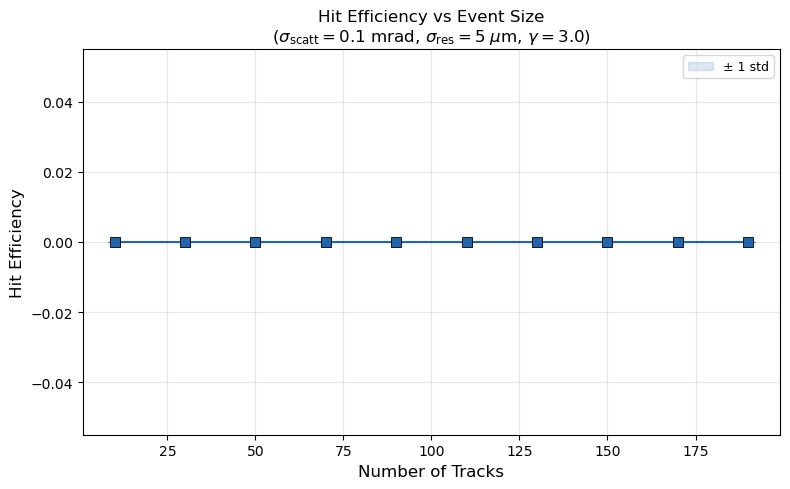

Individual metric plots saved.


In [12]:
# ── Individual per-metric plots (larger, for closer inspection) ────
for metric in ES_METRIC_KEYS:
    fig, ax = plt.subplots(figsize=(8, 5))

    y_mean = agg_es[(metric, "mean")].values
    y_se   = agg_es[(metric, "_se")].values

    ax.errorbar(
        x_vals, y_mean, yerr=y_se,
        fmt="s-", color="#2166ac",
        capsize=5, capthick=1.2,
        markeredgecolor="black", markeredgewidth=0.6,
        markersize=7,
    )
    # Shade ±1 std band
    y_std = agg_es[(metric, "std")].values
    ax.fill_between(x_vals, y_mean - y_std, y_mean + y_std,
                    alpha=0.15, color="#2166ac", label="± 1 std")

    ax.set_xlabel("Number of Tracks", fontsize=12)
    ax.set_ylabel(ES_METRIC_LABELS[metric], fontsize=12)
    ax.set_title(
        f"{ES_METRIC_LABELS[metric]} vs Event Size\n"
        rf"($\sigma_{{\mathrm{{scatt}}}} = {SIGMA_SCATT*1e3:.1f}$ mrad, "
        rf"$\sigma_{{\mathrm{{res}}}} = {SIGMA_RES*1e3:.0f}\;\mu$m, "
        rf"$\gamma = {GAMMA_ES}$)",
        fontsize=12,
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"event_size_{metric}.pdf", bbox_inches="tight")
    fig.savefig(OUT_DIR / f"event_size_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Individual metric plots saved.")

In [13]:
# ── Save per-event results to CSV ─────────────────────────────────
df_es.to_csv(OUT_DIR / "event_size_sweep_results.csv", index=False)
print(f"Per-event results saved to {OUT_DIR / 'event_size_sweep_results.csv'}")

Per-event results saved to outputs/event_size_sweep_results.csv


---

## 7. Large-Event Analysis (up to 1000 Tracks)

Extends the event-size study to 1000 tracks using:
- **AcceleratedHamiltonian** (Numba-parallel) for feasible build times
- **Condor batch jobs** for high statistics (50 events per point)
- **Corrected threshold** $= (\text{baseline} + \text{max chain activation})/2 = 0.375$

| Parameter | Value |
|-----------|-------|
| Track counts | 10, 50, 100, 200, 300, 500, 700, 1000 |
| Events per point | 50 |
| $\gamma$ | 3.0 |
| All other params | same as Section 6 |

Results are loaded from `results_large/aggregated/` produced by the Condor pipeline.

In [1]:
# ── Load Condor results ───────────────────────────────────────────
import pandas as pd
from pathlib import Path

LARGE_AGG_DIR = Path("results_large/aggregated")

df_large = pd.read_csv(LARGE_AGG_DIR / "reco_large.csv")
df_large_ev = pd.read_csv(LARGE_AGG_DIR / "reco_large_per_event.csv")

print(f"Loaded {len(df_large)} aggregated points, {len(df_large_ev)} per-event rows")
print(f"Track counts: {sorted(df_large['n_tracks'].unique())}")
print(f"Events per point: {df_large['n_events'].iloc[0]}")
print(f"Gamma={df_large['gamma'].iloc[0]}, Threshold={df_large['threshold'].iloc[0]}")
df_large[["n_tracks", "efficiency_mean", "efficiency_se",
          "ghost_rate_mean", "ghost_rate_se",
          "clone_fraction_mean", "mean_purity_mean",
          "hit_efficiency_mean", "wall_time_total_s"]]

Loaded 8 aggregated points, 400 per-event rows
Track counts: [np.int64(10), np.int64(50), np.int64(100), np.int64(200), np.int64(300), np.int64(500), np.int64(700), np.int64(1000)]
Events per point: 50
Gamma=3.0, Threshold=0.375


,n_tracks,efficiency_mean,efficiency_se,ghost_rate_mean,ghost_rate_se,clone_fraction_mean,mean_purity_mean,hit_efficiency_mean,wall_time_total_s
0,10,0.888000,0.022613,0.000000,0.000000,0.0,0.999600,0.600400,1.07
1,50,0.914800,0.017189,0.000000,0.000000,0.0,1.000000,0.600000,4.26
2,100,0.935800,0.015647,0.004773,0.004168,0.0,0.999328,0.600672,15.32
3,200,0.868900,0.025103,0.010513,0.005050,0.0,0.978888,0.589132,68.33
4,300,0.897733,0.020490,0.014215,0.007084,0.0,0.999089,0.600986,153.05
5,500,0.891200,0.020514,0.009050,0.005161,0.0,0.999357,0.600520,520.01
6,700,0.875029,0.030609,0.040711,0.020483,0.0,0.978567,0.588875,894.10
7,1000,0.840440,0.031544,0.032603,0.006754,0.0,0.997949,0.601082,2900.62


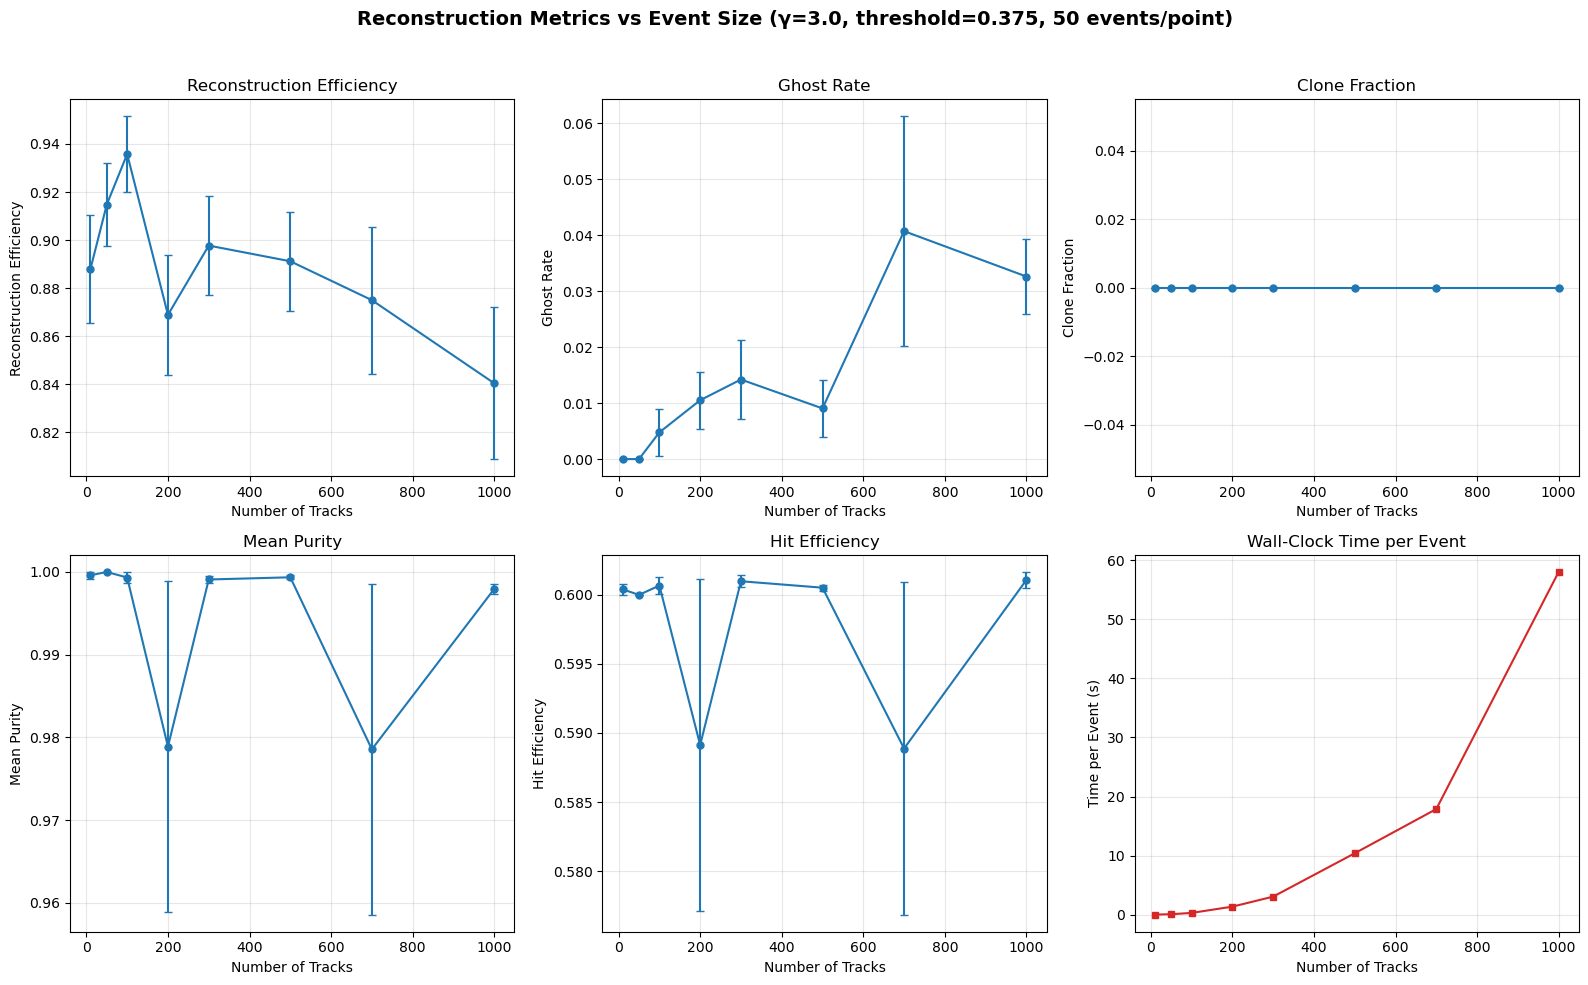

Combined large-event metrics plot saved.


In [2]:
# ── Reconstruction metrics vs event size (large events) ───────────
import matplotlib.pyplot as plt
import numpy as np

LARGE_METRICS = ["efficiency", "ghost_rate", "clone_fraction", "mean_purity", "hit_efficiency"]
LARGE_LABELS = {
    "efficiency":     "Reconstruction Efficiency",
    "ghost_rate":     "Ghost Rate",
    "clone_fraction": "Clone Fraction",
    "mean_purity":    "Mean Purity",
    "hit_efficiency": "Hit Efficiency",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, metric in enumerate(LARGE_METRICS):
    ax = axes[idx]
    mean_col = f"{metric}_mean"
    se_col   = f"{metric}_se"
    x = df_large["n_tracks"]
    y = df_large[mean_col]
    yerr = df_large[se_col]
    ax.errorbar(x, y, yerr=yerr, marker='o', capsize=3, linewidth=1.5, markersize=5)
    ax.set_xlabel("Number of Tracks")
    ax.set_ylabel(LARGE_LABELS[metric])
    ax.set_title(LARGE_LABELS[metric])
    ax.grid(True, alpha=0.3)

# Timing in last panel
ax = axes[-1]
ax.plot(df_large["n_tracks"], df_large["wall_time_total_s"] / df_large["n_events"],
        marker='s', color='tab:red', linewidth=1.5, markersize=5)
ax.set_xlabel("Number of Tracks")
ax.set_ylabel("Time per Event (s)")
ax.set_title("Wall-Clock Time per Event")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Reconstruction Metrics vs Event Size (γ={df_large['gamma'].iloc[0]}, "
             f"threshold={df_large['threshold'].iloc[0]}, {int(df_large['n_events'].iloc[0])} events/point)",
             fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)
fig.savefig(OUT_DIR / "large_event_metrics_combined.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "large_event_metrics_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print("Combined large-event metrics plot saved.")

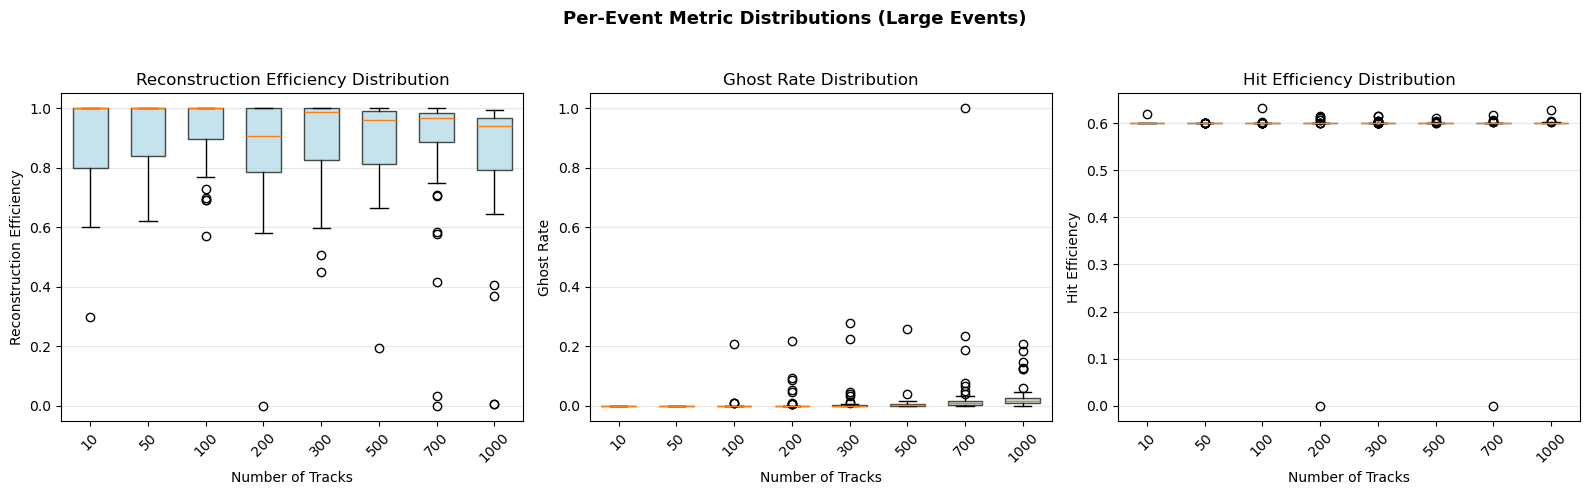

Box plot distributions saved.


In [3]:
# ── Per-event distribution (box plots) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, metric in enumerate(["efficiency", "ghost_rate", "hit_efficiency"]):
    ax = axes[idx]
    track_vals = sorted(df_large_ev["n_tracks"].unique())
    data_per_group = [df_large_ev[df_large_ev["n_tracks"] == n][metric].values for n in track_vals]

    bp = ax.boxplot(data_per_group, positions=range(len(track_vals)),
                    widths=0.6, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    ax.set_xticks(range(len(track_vals)))
    ax.set_xticklabels(track_vals, rotation=45)
    ax.set_xlabel("Number of Tracks")
    ax.set_ylabel(LARGE_LABELS[metric])
    ax.set_title(f"{LARGE_LABELS[metric]} Distribution")
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle("Per-Event Metric Distributions (Large Events)", fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "large_event_boxplots.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "large_event_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Box plot distributions saved.")

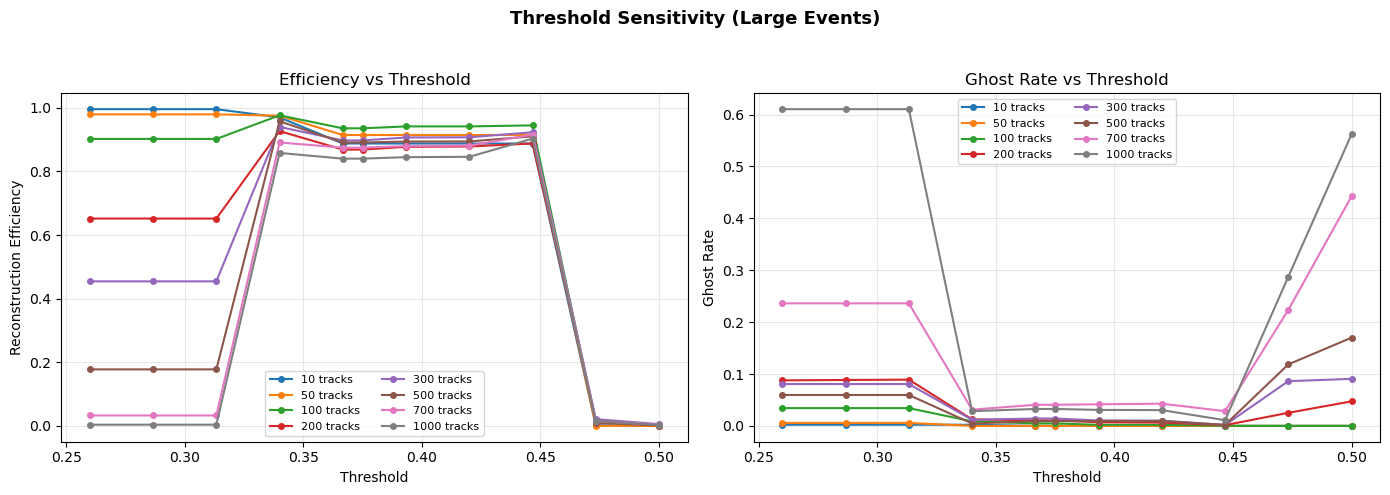

Threshold sensitivity plot saved.


In [5]:
# ── Threshold sensitivity analysis ─────────────────────────────────
thr_csv = LARGE_AGG_DIR / "reco_large_thr_sweep.csv"
if thr_csv.exists():
    df_thr = pd.read_csv(thr_csv)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for n_trk in sorted(df_thr["n_tracks"].unique()):
        sub = df_thr[df_thr["n_tracks"] == n_trk]
        ax1.plot(sub["threshold"], sub["efficiency_mean"], marker='o', markersize=4,
                 label=f"{n_trk} tracks")
        ax2.plot(sub["threshold"], sub["ghost_rate_mean"], marker='o', markersize=4,
                 label=f"{n_trk} tracks")

    ax1.set_xlabel("Threshold")
    ax1.set_ylabel("Reconstruction Efficiency")
    ax1.set_title("Efficiency vs Threshold")
    ax1.legend(fontsize=8, ncol=2)
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel("Threshold")
    ax2.set_ylabel("Ghost Rate")
    ax2.set_title("Ghost Rate vs Threshold")
    ax2.legend(fontsize=8, ncol=2)
    ax2.grid(True, alpha=0.3)

    fig.suptitle("Threshold Sensitivity (Large Events)", fontsize=13, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(OUT_DIR / "large_event_threshold_sensitivity.pdf", bbox_inches="tight")
    fig.savefig(OUT_DIR / "large_event_threshold_sensitivity.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Threshold sensitivity plot saved.")
else:
    print("No threshold sweep data available.")

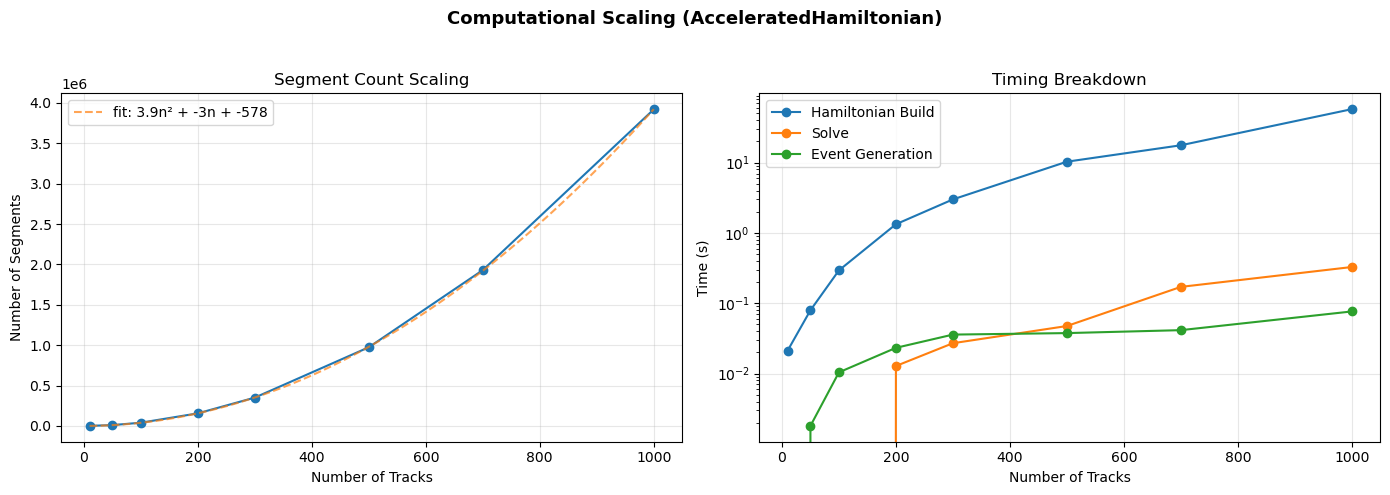

Scaling analysis plot saved.


In [6]:
# ── Scaling analysis: segments and timing ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Segments vs tracks (should be ~ n^2)
n_segs = df_large_ev.groupby("n_tracks")["n_segments"].mean()
ax1.plot(n_segs.index, n_segs.values, 'o-', color='tab:blue', linewidth=1.5)
# Fit quadratic
from numpy.polynomial import polynomial as P
c = P.polyfit(n_segs.index.astype(float), n_segs.values, 2)
x_fit = np.linspace(n_segs.index.min(), n_segs.index.max(), 100)
y_fit = P.polyval(x_fit, c)
ax1.plot(x_fit, y_fit, '--', color='tab:orange', alpha=0.7,
         label=f"fit: {c[2]:.1f}n² + {c[1]:.0f}n + {c[0]:.0f}")
ax1.set_xlabel("Number of Tracks")
ax1.set_ylabel("Number of Segments")
ax1.set_title("Segment Count Scaling")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Timing breakdown
for col, label, color in [("t_build_s", "Hamiltonian Build", "tab:blue"),
                           ("t_solve_s", "Solve", "tab:orange"),
                           ("t_generate_s", "Event Generation", "tab:green")]:
    if col in df_large_ev.columns:
        means = df_large_ev.groupby("n_tracks")[col].mean()
        ax2.plot(means.index, means.values, 'o-', label=label, color=color, linewidth=1.5)

ax2.set_xlabel("Number of Tracks")
ax2.set_ylabel("Time (s)")
ax2.set_title("Timing Breakdown")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale("log")

fig.suptitle("Computational Scaling (AcceleratedHamiltonian)", fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "large_event_scaling.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "large_event_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Scaling analysis plot saved.")